## Intro


In [ ]:
# what & why  pydantic - 
# Pydantic is a data validation and settings management library for Python. 
# It allows you to define data models using Python classes, and it provides powerful tools for validating and parsing data. 
# Pydantic is often used in web development, data processing, and any situation where you need to ensure that the data you're working with conforms to a specific structure or format.

# since python is dynamically typed, it can lead to issues where you might accidentally pass the wrong type of data to a function or class.
# Pydantic helps to mitigate these issues by allowing you to define data models with type annotations.
# It also provides features like data parsing, serialization, and error handling, making it easier to work with complex data structures.

# in python there no type validation, so you can pass any type of data to a function or class, which can lead to unexpected behavior or errors.
# pydantic make sure you dont have to worry about type validation and data validation, it will handle that for you.

# how to build a pydantic model -



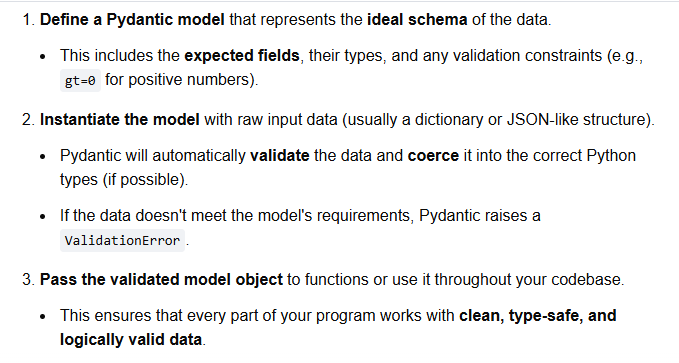

In [1]:
! pip install pydantic

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# example when pydantic is not used -

def insert_patient_data(name,age):

    print(name)
    print(age)
    print("Record Inserted")

insert_patient_data("John Doe", 30) # this will work fine
insert_patient_data("John Doe", "thirty") # this will also work fine, but it is not correct, age should be an integer


John Doe
30
Record Inserted
John Doe
thirty
Record Inserted


In [14]:
# step 1 - creating pydantic model where we represent the ideal schema

from pydantic import BaseModel

class Patient(BaseModel):
    name: str # fields with type annotations
    age: int  # required fields, if we try to create an object of the model without these fields, it will raise an error



def insert_patient_data(patient: Patient): # pydanctic object

    print(patient.name)  
    print(patient.age)
    print("Record Inserted")

patient_info = {'name': 'John Doe', 'age': 30}

# step 2 - creating an object of the pydantic model and passing the data to it, this will validate the data and if it is valid, it will create an object of the model, if it is not valid, it will raise an error.
patient1 = Patient(**patient_info) # this will create a patient object with the given data

# step 3 - passing the pydantic object to the function, this will ensure that the data is valid and it will work as expected.
insert_patient_data(patient1) # this will work fine

John Doe
30
Record Inserted


In [15]:
patient_info = {'name': 'John Doe', 'age': 'thirty'}
#patient2 = Patient(**patient_info) # this will raise an Validation error, because age should be an integer, but it is a string

In [10]:
patient_info = {'name': 'John Doe', 'age': '30'} 
patient3 = Patient(**patient_info) # this will work fine, because pydantic will try to convert the string to an integer, if it is possible, it will convert it, if it is not possible, it will raise an error
insert_patient_data(patient3) # this will work fine, because patient3 is a valid patient

John Doe
30
Record Inserted


In [18]:
from typing import List, Optional, Dict


class Patient(BaseModel):
    
    # required fields

    name: str
    age : int
    weight: float
    married : bool = False # setting default value to False, if we try to create an object of the model without this field, it will take the default value
    address: str = None
    contact_deatails : Dict[str, str] # this field should be a dictionary with string keys and string values, if we try to create an object of the model with a different type of data, it will raise an error
    # optional fields

    
    allergies: Optional[List[str]] = None 


def insert_patient_data(patient: Patient):

    print(patient.name)  
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.contact_deatails)
    print(patient.address)
    print(patient.allergies)
    print("Record Inserted")


patient_info = {
    'name': 'John Doe',
    'age': 30,
    'weight': 70.5,
    'married': True,
    'contact_deatails': {'email': 'john.doe@example.com', 'phone': '123-456-7890'},
    'address': '123 Main St, Anytown, USA',
    'allergies': ['Peanuts', 'Shellfish']
}

patient1 = Patient(**patient_info)
insert_patient_data(patient1)

John Doe
30
70.5
True
{'email': 'john.doe@example.com', 'phone': '123-456-7890'}
123 Main St, Anytown, USA
['Peanuts', 'Shellfish']
Record Inserted


In [20]:
# edge case that wont work 

patient_info = {
    'name': 'John Doe',
    'age': 30,
    'weight': 70.5,
    'married': True,
    'contact_deatails': {'email': 'john.doe@example.com', 'phone': '123-456-7890'},
    'hobbies': ['Reading', 'Traveling'] # this field is not defined in the model, so it will raise an error
}

patient2 = Patient(**patient_info)
insert_patient_data(patient2)


John Doe
30
70.5
True
{'email': 'john.doe@example.com', 'phone': '123-456-7890'}
None
None
Record Inserted


In [22]:
pip install pydantic[email]

Defaulting to user installation because normal site-packages is not writeable
  Using cached email_validator-2.3.0-py3-none-any.whl.metadata (26 kB)
  Using cached dnspython-2.8.0-py3-none-any.whl.metadata (5.7 kB)
Using cached email_validator-2.3.0-py3-none-any.whl (35 kB)
Using cached dnspython-2.8.0-py3-none-any.whl (331 kB)

   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ---------------------------------------- 0/2 [dnspython]
   ------


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
# example using Emali  , anyurl 

from pydantic import BaseModel, EmailStr, AnyUrl
from typing import Optional

class Patient(BaseModel):
    name: str
    email: EmailStr # this field should be a valid email address, if we try to create an object of the model with an invalid email address, it will raise an error
    website: Optional[AnyUrl] = None # this field should be a valid URL, if we try to create an object of the model with an invalid URL, it will raise an error, if we try to create an object of the model without this field, it will take the default value of None

patient1 = Patient(name='John Doe', email='john.doe@example.com', website='https://www.example.com')
patient2 = Patient(name='Jane Doe', email='jane.doe@example.com')
#patient3 = Patient(name='Invalid Email', email='invalid-email') # this will raise an error, because the email address is not valid

def insert_patient_data(patient: Patient):
    print(patient.name)
    print(patient.email)
    print(patient.website)
    print("Record Inserted")

insert_patient_data(patient1)
insert_patient_data(patient2)



John Doe
john.doe@example.com
https://www.example.com/
Record Inserted
Jane Doe
jane.doe@example.com
None
Record Inserted


In [24]:
# what if user want a custom validation according to busines usecase
# pydantic provides Field class which allows us to define custom validation for the fields, we can use it to define custom validation for the fields in our model.


from pydantic import BaseModel, Field
from typing import Optional,List,Dict

class Patient(BaseModel):
    name: str = Field(min_length=2, max_length=50) # this field is required, it should be a string with a minimum length of 2 and a maximum length of 50, if we try to create an object of the model with a string that does not meet these criteria, it will raise an error
    age: int = Field(gt=0, lt=150) # this field is required, it should be an integer greater than 0 and less than 150, if we try to create an object of the model with an integer that does not meet these criteria, it will raise an error
    weight: float = Field(gt=0) # this field is required, it should be a float greater than 0, if we try to create an object of the model with a float that does not meet this criteria, it will raise an error
    married: bool = False
    address: str = None
    contact_deatails : Dict[str, str]
    allergies: Optional[List[str]] = None

def insert_patient_data(patient: Patient):
    print(patient.name)
    print(patient.age)
    print(patient.weight)
    print(patient.married)
    print(patient.contact_deatails)
    print(patient.address)
    print(patient.allergies)
    print("Record Inserted")

patient_info = {
    'name': 'John Doe',
    'age': 30,
    'weight': 70.5,
    'married': True,
    'contact_deatails': {'email': 'john.doe@example.com', 'phone': '123-456-7890'}
}

patient1 = Patient(**patient_info)
insert_patient_data(patient1)

John Doe
30
70.5
True
{'email': 'john.doe@example.com', 'phone': '123-456-7890'}
None
None
Record Inserted


In [ ]:
# adding metadata to field so that it can useful via api calls , attaching metadata using Anotation and Field class

# simple example using field and annotation 

from pydantic import BaseModel, Field
from typing import Optional, Dict, List, 

